In [2]:
import pandas as pd
import matplotlib.pyplot as plt 

netflix_data = pd.read_csv(r"C:\Users\ASUS\Downloads\netflix_content.csv")
netflix_data.head()

,Title,Available Globally?,Release Date,Hours Viewed,Language Indicator,Content Type
0,The Night Agent: Season 1,Yes,2023-03-23,"81,21,00,000",English,Show
1,Ginny & Georgia: Season 2,Yes,2023-01-05,"66,51,00,000",English,Show
2,The Glory: Season 1 // 더 글로리: 시즌 1,Yes,2022-12-30,"62,28,00,000",Korean,Show
3,Wednesday: Season 1,Yes,2022-11-23,"50,77,00,000",English,Show
4,Queen Charlotte: A Bridgerton Story,Yes,2023-05-04,"50,30,00,000",English,Movie


In [3]:
netflix_data['Hours Viewed'] = netflix_data['Hours Viewed'].replace(',','',regex = True).astype(float)
netflix_data[['Title','Hours Viewed']].head()

,Title,Hours Viewed
0,The Night Agent: Season 1,812100000.0
1,Ginny & Georgia: Season 2,665100000.0
2,The Glory: Season 1 // 더 글로리: 시즌 1,622800000.0
3,Wednesday: Season 1,507700000.0
4,Queen Charlotte: A Bridgerton Story,503000000.0


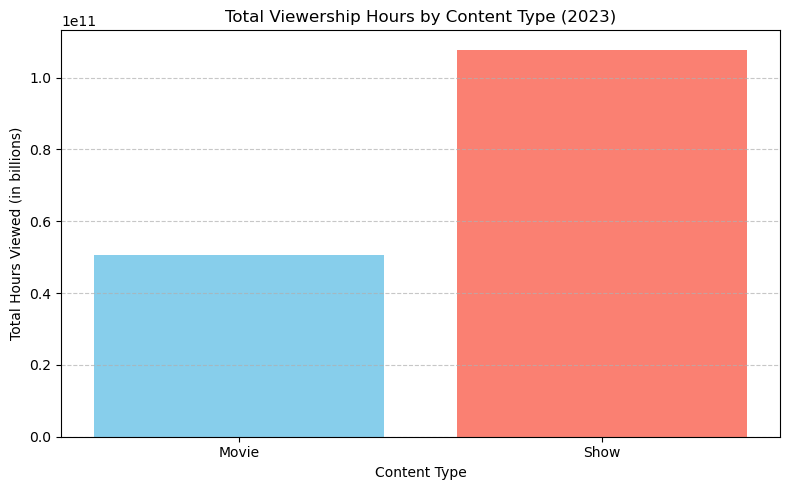

In [4]:
content_type_viewership = netflix_data.groupby('Content Type')['Hours Viewed'].sum()
plt.figure(figsize=(8,5))
plt.bar(content_type_viewership.index,content_type_viewership.values,color=['skyblue','salmon'])
plt.title('Total Viewership Hours by Content Type (2023)')
plt.xlabel('Content Type')
plt.ylabel('Total Hours Viewed (in billions)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

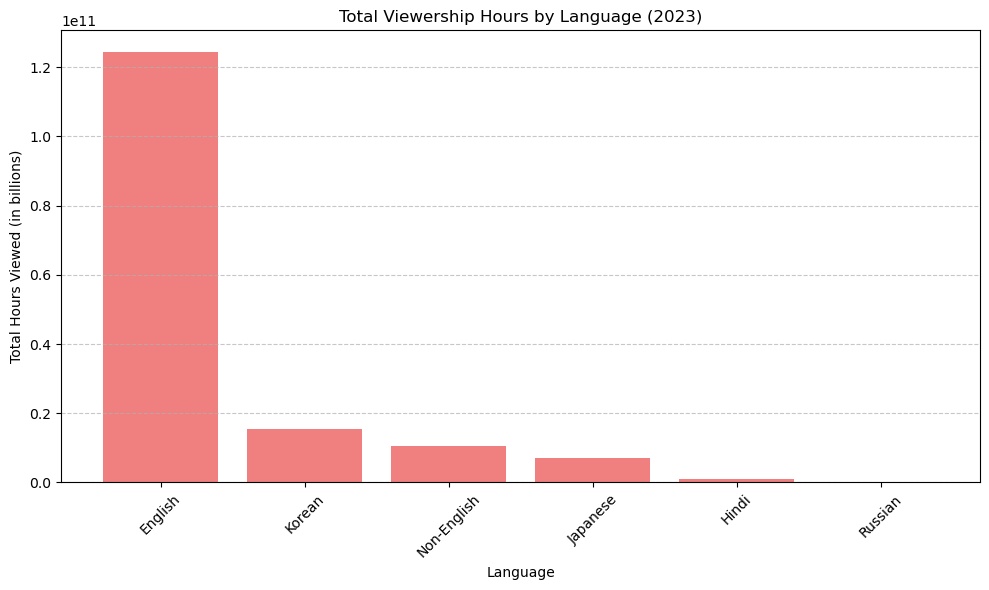

In [5]:
language_viewership = netflix_data.groupby('Language Indicator')['Hours Viewed'].sum().sort_values(ascending = False)
plt.figure(figsize=(10,6))
plt.bar(language_viewership.index,language_viewership.values,color='lightcoral')
plt.title('Total Viewership Hours by Language (2023)')
plt.xlabel('Language')
plt.ylabel('Total Hours Viewed (in billions)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

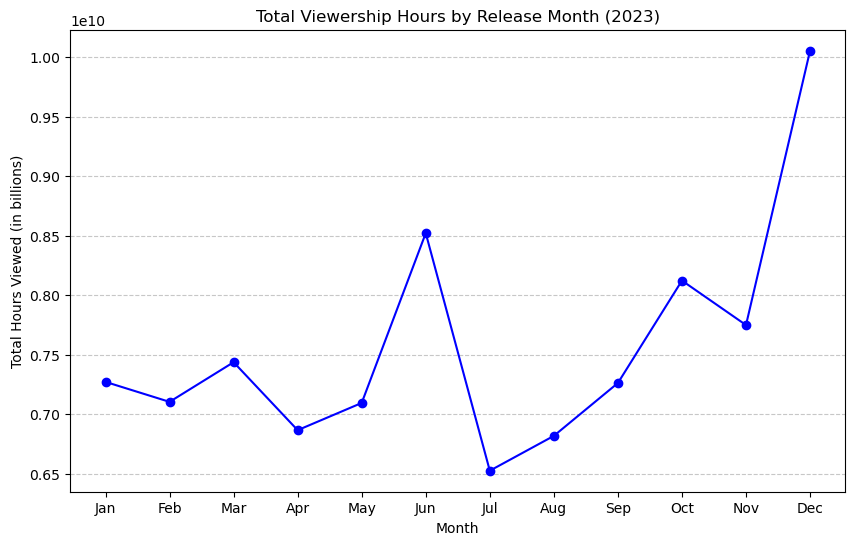

In [9]:
netflix_data['Release Date'] = pd.to_datetime(netflix_data['Release Date'])
netflix_data['Release Month'] = netflix_data['Release Date'].dt.month

monthly_viewership = netflix_data.groupby('Release Month')['Hours Viewed'].sum()
plt.figure(figsize=(10, 6))
plt.plot(monthly_viewership.index, monthly_viewership.values, marker='o', color='blue', linestyle='-')
plt.title('Total Viewership Hours by Release Month (2023)')
plt.xlabel('Month')
plt.ylabel('Total Hours Viewed (in billions)')
plt.xticks(ticks=range(1, 13), labels=months)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [10]:
top_5_titles= netflix_data.nlargest(5,'Hours Viewed')
top_5_titles[['Title','Hours Viewed','Language Indicator','Content Type','Release Date']]


,Title,Hours Viewed,Language Indicator,Content Type,Release Date
0,The Night Agent: Season 1,812100000.0,English,Show,2023-03-23
1,Ginny & Georgia: Season 2,665100000.0,English,Show,2023-01-05
18227,King the Land: Limited Series // 킹더랜드: 리미티드 시리즈,630200000.0,Korean,Movie,2023-06-17
2,The Glory: Season 1 // 더 글로리: 시즌 1,622800000.0,Korean,Show,2022-12-30
18214,ONE PIECE: Season 1,541900000.0,English,Show,2023-08-31


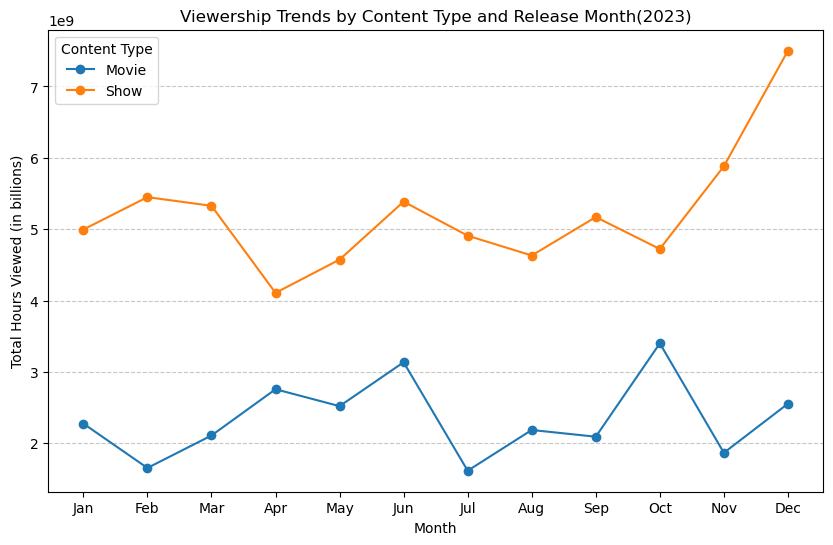

In [12]:
monthly_viewership_by_type = netflix_data.pivot_table(index='Release Month',columns='Content Type',values='Hours Viewed',aggfunc='sum')
plt.figure(figsize=(10,6))
for content_type in monthly_viewership_by_type.columns:
    plt.plot(monthly_viewership_by_type.index,
            monthly_viewership_by_type[content_type],
            marker='o',label=content_type)
plt.title('Viewership Trends by Content Type and Release Month(2023)')
plt.xlabel('Month')
plt.ylabel('Total Hours Viewed (in billions)')
plt.xticks(ticks=range(1,13),labels=months)
plt.legend(title='Content Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

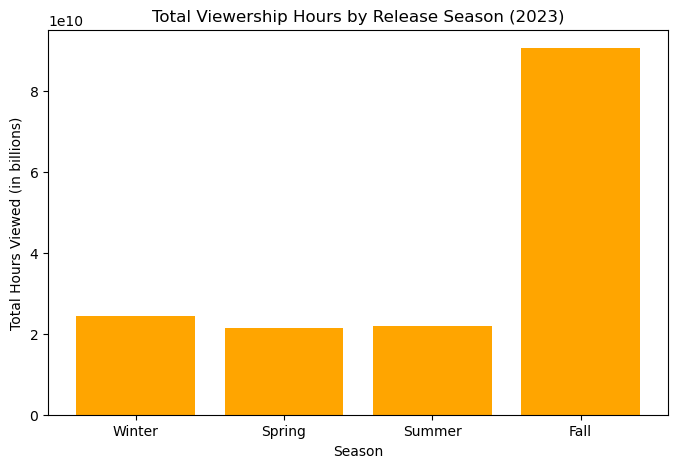

In [14]:
def get_season(month):
    if month in[12,1,2]:
        return 'Winter'
    elif month in[3,4,5]:
        return 'Spring'
    elif month in[6,7,8]:
        return 'Summer'
    else:
        return 'Fall'
netflix_data['Release Season'] = netflix_data['Release Month'].apply(get_season)
seasonal_viewership =netflix_data.groupby('Release Season')['Hours Viewed'].sum()
seasons_order = ['Winter', 'Spring', 'Summer', 'Fall']
seasonal_viewership = seasonal_viewership.reindex(seasons_order)

plt.figure(figsize=(8, 5))
plt.bar(
    seasonal_viewership.index,
    seasonal_viewership.values,
    color='orange'
)

plt.title('Total Viewership Hours by Release Season (2023)')
plt.xlabel('Season')
plt.ylabel('Total Hours Viewed (in billions)')
plt.xticks(rotation=0)
plt.show()

    
    

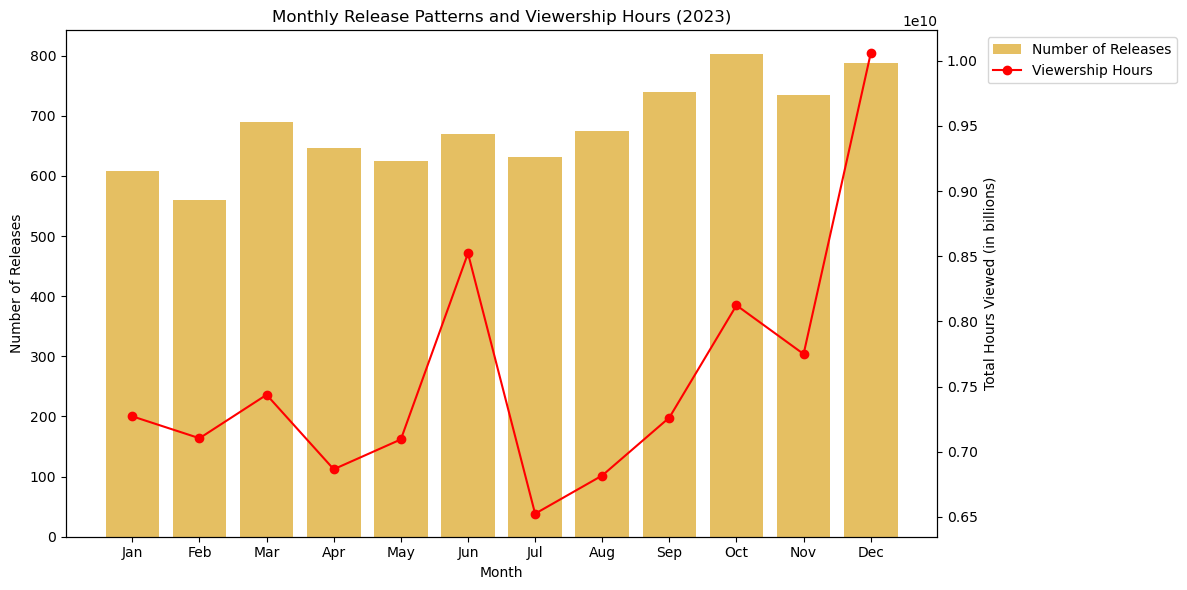

In [17]:
monthly_releases = netflix_data['Release Month'].value_counts().sort_index()
monthly_viewership = netflix_data.groupby('Release Month')['Hours Viewed'].sum()

fig,ax1=plt.subplots(figsize=(12,6))
ax1.bar(monthly_releases.index,monthly_releases.values,color='goldenrod',alpha=0.7,label='Number of Releases')
ax1.set_xlabel('Month')
ax1.set_ylabel('Number of Releases')
ax1.set_xticks(range(1,13))
ax1.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul',
                     'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax1.tick_params(axis='x',rotation=0)
ax2=ax1.twinx()
ax2.plot(monthly_viewership.index,monthly_viewership.values,color='red',marker='o',label='Viewership Hours')
ax2.set_ylabel('Total Hours Viewed (in billions)')
plt.title("Monthly Release Patterns and Viewership Hours (2023)")

lines_1,labels_1=ax1.get_legend_handles_labels()
lines_2,labels_2=ax2.get_legend_handles_labels()
ax1.legend(lines_1+lines_2,labels_1+labels_2,loc='upper left',bbox_to_anchor=(1.05,1))

plt.tight_layout()
plt.show()

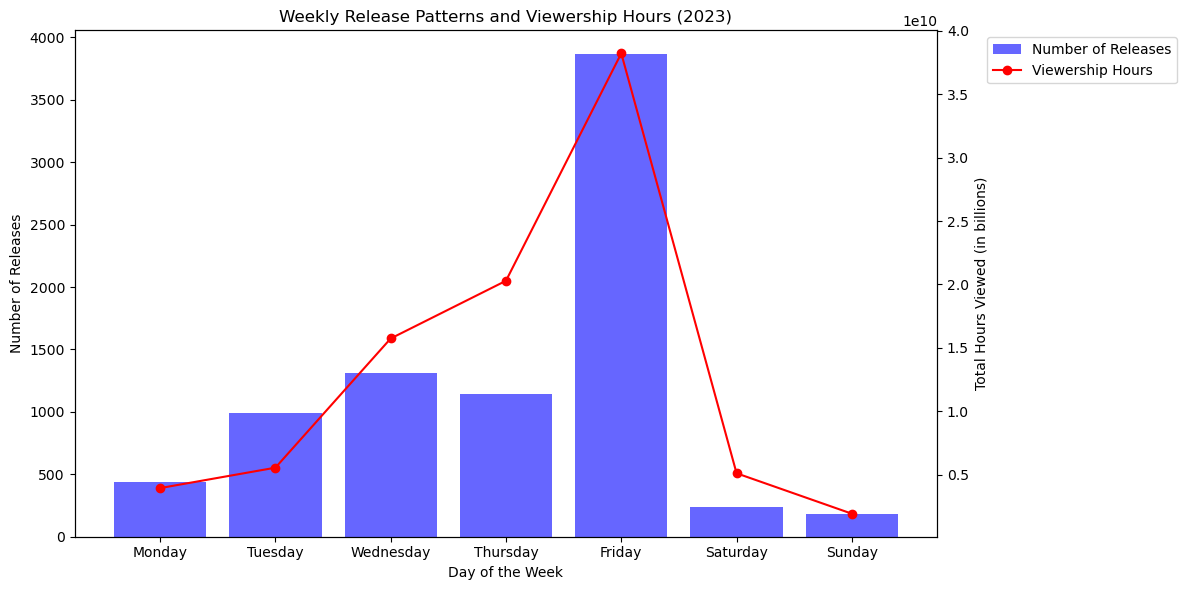

In [18]:
netflix_data['Release Day']= netflix_data['Release Date'].dt.day_name()
weekday_releases = netflix_data['Release Day'].value_counts().reindex(
    ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
weekday_viewership = netflix_data.groupby('Release Day')['Hours Viewed'].sum().reindex(
    ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])

fig,ax1=plt.subplots(figsize=(12,6))
ax1.bar(weekday_releases.index,weekday_releases.values,color='blue',alpha =0.6,label='Number of Releases')
ax1.set_xlabel('Day of the Week')
ax1.set_ylabel('Number of Releases')
ax1.set_xticks(range(len(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])))
ax1.set_xticklabels(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])

ax1.set_title("Weekly Release Patterns and Viewership Hours (2023)")

ax2=ax1.twinx()
ax2.plot(weekday_viewership.index,weekday_viewership.values,color='red',marker='o',label='Viewership Hours')
ax2.set_ylabel("Total Hours Viewed (in billions)")

lines_1,labels_1=ax1.get_legend_handles_labels()
lines_2,labels_2=ax2.get_legend_handles_labels()
ax1.legend(lines_1+lines_2,labels_1+labels_2,loc='upper left',bbox_to_anchor=(1.05,1))

plt.tight_layout()
plt.show()

In [ ]:
important_dates = ['2023-01-01','2023-02-14','2023-07-04','2023-10-31','2023-12-25']
important_dates = pd.to_datetime(important_dates)

holiday_releases = netflix_data[netflix_data['Release Date']].apply(
lambda x: any((x-date).days in range(-3,4) for date)) 